# Watch the decades: animated maps and temporal comparisons

**Time:** 40 minutes · **Prerequisites:** basic Python; run cells from top to bottom.

Build an animated map of the published aggregates; keep scales fixed; choose between animation and small multiples.

[Run this notebook in JupyterLite](https://jltobias.github.io/JupyterLite-Sea-Level-Rise/lite/lab/index.html?path=notebooks/06_time_series_maps.ipynb) · [Full-screen dashboard](https://jltobias.github.io/JupyterLite-Sea-Level-Rise/dashboard/) · [Official poster](https://plus.iasociety.org/sites/default/files/2024-09/e-poster_755.pdf)

Each notebook runs independently. Use **Run → Run All Cells**; the first package download can take a minute. Save a downloaded copy to keep your work. The read-only book includes executed examples.

In [1]:
# First run downloads Python packages in JupyterLite; subsequent runs use browser caches.
import sys
if sys.platform == 'emscripten':
    import piplite
    await piplite.install(['numpy', 'pandas', 'matplotlib', 'plotly', 'ipywidgets'])
from pathlib import Path
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display, HTML
from coastlab import (DATA, SCENARIOS, YEARS, COLORS, load_data, select, cards,
                      toy_slr, toy_probability, cumulative_probability,
                      haversine_km, show, dashboard, land_traces)
facilities, exposure = load_data()
published = pd.read_csv(DATA / 'poster_aggregates.csv')
print('Ready: public poster aggregates + clearly labeled fictional facility fixtures.')

Ready: public poster aggregates + clearly labeled fictional facility fixtures.


## Time is a dimension, not a slide transition

An animation can reveal the sequence of change, but it taxes memory: a reader must remember an earlier frame. Fixed-scale small multiples support direct comparisons. Keep the same locations, denominator, marker-size rule and colour scale across frames.

This map uses five **city** rows from the poster, not district rows or all portfolio sites. The 2023 denominator is held fixed, as in the source tables. The time steps are modeled decades; the animation does not imply that exposure changes only once each decade.

In [2]:
city=published.query("scope == 'city' and scenario == 'RCP 8.5'").copy()
fig=px.scatter(city,x='longitude',y='latitude',animation_frame='year',animation_group='city',
    size='potentially_flooded',size_max=45,color='percent',range_color=[0,100],
    hover_name='city',hover_data=['facilities_2023','potentially_flooded'],
    range_x=[-15,120],range_y=[-12,25],color_continuous_scale='YlOrRd',
    title='Published RCP 8.5 city counts, 2030–2100')
for trace in land_traces(): fig.add_trace(trace)
fig.update_layout(xaxis_title='Longitude (°)',yaxis_title='Latitude (°)')
show(fig)

<iframe title="Interactive teaching figure" style="width:100%;height:560px;border:0" srcdoc="<!doctype html>
<html>
<head>
 <meta charset="utf-8" />
 <style>html, body {height: 100%;}</style>
</head>
<body>
 <div style="height:100%; width:100%;"> <script>window.PlotlyConfig = {MathJaxConfig: 'local'};</script>
 <script charset="utf-8" src="../../assets/plotly.min.js"></script> <div id="bc88fd69-2b2a-488e-aee2-6fca8c270d16" class="plotly-graph-div" style="height:100%; width:100%;"></div> <script> window.PLOTLYENV=window.PLOTLYENV || {}; if (document.getElementById("bc88fd69-2b2a-488e-aee2-6fca8c270d16")) { Plotly.newPlot( "bc88fd69-2b2a-488e-aee2-6fca8c270d16", [{"customdata":{"dtype":"i1","bdata":"IgETDSwASQAcAA==","shape":"5, 2"},"hovertemplate":"\u003cb\u003e%{hovertext}\u003c\u002fb\u003e\u003cbr\u003e\u003cbr\u003eyear=2030\u003cbr\u003elongitude=%{x}\u003cbr\u003elatitude=%{y}\u003cbr\u003epotentially_flooded=%{customdata[1]}\u003cbr\u003efacilities_2023=%{customdata[0]}\u003cbr\u003epercent=%{marker.color}\u003cextra\u003e\u003c\u002fextra\u003e","hovertext":["Abidjan","Bangkok","Ho Chi Minh City","Lagos","Mombasa"],"ids":["Abidjan","Bangkok","Ho Chi Minh City","Lagos","Mombasa"],"legendgroup":"","marker":{"color":{"dtype":"f8","bdata":"K\u002faX3ZOHB0AeFmpN8xpRQAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA=="},"coloraxis":"coloraxis","size":{"dtype":"i1","bdata":"AQ0AAAA="},"sizemode":"area","sizeref":0.013827160493827161,"symbol":"circle"},"mode":"markers","name":"","orientation":"v","showlegend":false,"x":{"dtype":"f8","bdata":"H4XrUbgeEMAAAAAAACBZQM3MzMzMrFpAH4XrUbgeC0D2KFyPwtVDQA=="},"xaxis":"x","y":{"dtype":"f8","bdata":"UrgehetRFUAAAAAAAIArQI\u002fC9ShcjyVAzczMzMzMGUAzMzMzMzMQwA=="},"yaxis":"y","type":"scatter"},{"hoverinfo":"skip","line":{"color":"#859a9e","width":0.6},"mode":"lines","name":"Natural Earth land","showlegend":false,"x":[-59.572095,-59.865849,-60.159656,-62.255393,-64.488125,-65.741666,-65.741666,-66.290031,-64.037688,-61.883246,-61.138976,-60.610119,-59.572095,null,-159.208184,-161.127601,-162.439847,-163.027408,-163.066604,-163.712896,-163.712896,-163.105801,-161.245113,-160.246208,-159.482405,-159.208184,null,-45.154758,-43.920828,-43.48995,-43.372438,-43.333267,-44.880537,-46.506174,-48.386421,-50.482107,-52.851988,-54.164259,-53.987991,-51.853134,-50.991326,-50.364595,-49.914131,-49.306959,-48.660616,-48.660616,-48.151396,-46.662857,-45.154758,null,-121.211511,-119.918851,-118.724143,-119.292119,-120.232217,-121.62283,-122.621735,-122.621735,-122.406245,-121.211511,null,-125.559566,-124.031882,-124.619469,-125.912181,-127.28313,-127.28313,-126.558472,-125.559566,null,-98.98155,-97.884743,-96.787937,-96.20035,-96.983765,-98.198083,-99.432013,-100.783455,-101.801868,-102.330725,-102.330725,-101.703967,-100.430919,-98.98155,null,-68.451346,-68.333834,-68.510128,-68.784297,-69.959471,-71.075889,-72.388134,-71.8985,-73.073622,-74.19004,-74.953895,-75.012625,-73.915819,-73.915819,-73.230331,-72.074717,-71.780962,-71.72218,-71.741791,-71.173815,-70.253252,-69.724447,-69.489422,-69.058518,-68.725541,-68.451346,null,-58.614143,-59.045073,-59.789342,-60.611928,-61.297416,-62.0221,-62.51176,-62.648858,-62.590128,-62.120079,-62.805567,-63.74569,-64.294106,-64.881693,-65.508425,-65.665082,-65.312545,-64.783715,-63.961103,-63.1973,-62.785955,-62.570516,-62.276736,-61.806661,-61.512906,-61.375809,-61.081977,-61.003661,-60.690269,-60.827367,-61.375809,-61.96337,-63.295201,-63.74569,-64.352836,-65.860987,-67.192818,-68.446282,-69.797724,-70.600724,-72.206776,-73.969536,-75.555977,-77.24037,-76.926979,-75.399294,-74.282876,-73.656119,-74.772536,-76.4961,-77.925858,-77.984666,-78.023785,-76.848637,-76.633224,-75.360097,-73.244852,-71.442946,-70.013163,-68.191646,-65.704279,-63.25603,-61.552026,-59.691416,-58.712121,-58.222487,-57.008117,-55.362894,-53.619771,-51.543644,-49.76135,-47.273931,-44.825708,-42.808363,-42.16202,-40.771433,-38.244818,-36.26667,-34.386397,-32.310296,-30.097098,-28.549802,-29.254901,-29.685805,-29.685

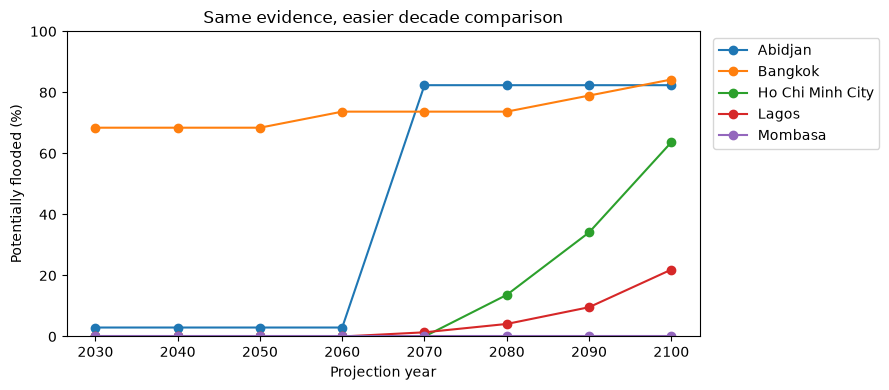

In [3]:
fig,ax=plt.subplots(figsize=(9,4))
for city_name,g in city.groupby('city'):
    ax.plot(g.year,g.percent,marker='o',label=city_name)
ax.set(xlabel='Projection year',ylabel='Potentially flooded (%)',ylim=(0,100),title='Same evidence, easier decade comparison')
ax.legend(bbox_to_anchor=(1.01,1),loc='upper left');fig.tight_layout();plt.show()

## A short narrated-by-captions visual

This locally bundled video is generated from the same fictional teaching function used in the labs. It shows all three curves and a moving year marker. It contains no observed flood footage and no audio. Captions and the adjacent transcript provide the explanation.

<video controls preload="metadata" style="width:100%" poster="../../assets/teaching-video-poster.png"><source src="../../assets/scenario-walkthrough.mp4" type="video/mp4"><track kind="captions" src="../../assets/scenario-walkthrough.vtt" srclang="en" label="English" default></video>

**Transcript:** The three curves use an invented 2020 baseline. Near-term trajectories are similar by construction. Later differences grow under the chosen endpoints. These are teaching curves, not a climate projection product. Exposure also depends on elevation, storm conditions, access and the definition of risk.

## Lab: choose an honest visual encoding

Create a 2 × 4 small-multiple plot for the eight published decades. Use city names on the horizontal axis and a fixed 0–100% vertical scale. Compare it with the animated map.

**Worked interpretation:** In the RCP 8.5 published city rows, Ho Chi Minh City rises from 0 in 2030 to 28/44 in 2100. Bangkok begins with a high share. A zero in the Mombasa row is a result under the study's definition and inputs; it does not mean the city has no climate hazards.

**Deliverable:** Pick the visual that best answers “which city's percentage changes most?” and justify it. Use animation to explain sequence; use a chart or table to support precise comparisons. External contextual videos listed in the references retain their owners' rights and are linked, not downloaded.